# `author_day` distribution per fold (16-fold LOOCV)

For each fold built by `2026-04-27_build_kfold_splits.py` the **val pool is a single `author_experimental_id`** (one h5ad). When that single run contains only one unique `author_day`, the one-hot signal handed to `latentmi` collapses to a constant column → `H(Y)=0` → MI is exactly 0. This notebook visualizes the per-fold `author_day` distribution to make the degenerate folds explicit.

Plots are inline only — nothing is saved to `final_results/`.

In [1]:
import json
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

KFOLD_DIR = Path('/home/igor/igor_repos/scaling_laws/data_local/other/batch_effects/kfold')
FOLDS = json.loads((KFOLD_DIR / 'folds.json').read_text())
ALL_IDS = FOLDS['all_ids']
print(f'{len(ALL_IDS)} ids, {len(FOLDS["folds"])} folds')

# Read author_day from each id's val h5ad once. Every id is the val of exactly
# one fold under LOOCV, so this gives us the per-id author_day distribution.
per_id_days: dict[str, pd.Series] = {}
for f in FOLDS['folds']:
    for vid in f['val_ids']:
        if vid in per_id_days:
            continue
        p = KFOLD_DIR / f'{f["fold"]+1}-fold' / 'val' / f'{vid}.h5ad'
        a = ad.read_h5ad(p)
        per_id_days[vid] = a.obs['author_day'].astype(str).reset_index(drop=True)
        del a
print('loaded', len(per_id_days), 'val h5ads')
all_days = sorted({d for s in per_id_days.values() for d in s.unique()})
print(f'{len(all_days)} unique author_day values overall: {all_days}')

16 ids, 16 folds


loaded 16 val h5ads
43 unique author_day values overall: ['E0800-E0850', 'E0875', 'E0900', 'E0925', 'E0950', 'E0975', 'E1000', 'E1025', 'E1050', 'E1075', 'E1100', 'E1125', 'E1150', 'E1175', 'E1200', 'E1225', 'E1250', 'E1275', 'E1300', 'E1325', 'E1350', 'E1375', 'E1400', 'E1425', 'E1433.3', 'E1475', 'E1500', 'E1525', 'E1550', 'E1575', 'E1600', 'E1625', 'E1650', 'E1675', 'E1700', 'E1725', 'E1750', 'E1775', 'E1800', 'E1825', 'E1850', 'E1875', 'P0000']


## 1. Per-id × author_day count matrix

Rows are sorted by id-name; cells are the number of cells in that id with that day. Empty cells mean the id has no representative of that day.

In [2]:
rows = []
for rid in ALL_IDS:
    counts = per_id_days[rid].value_counts()
    rows.append({d: int(counts.get(d, 0)) for d in all_days} | {'_id': rid})
M = pd.DataFrame(rows).set_index('_id').reindex(ALL_IDS)[all_days]
print('matrix shape:', M.shape)
print('row sums (n_cells per id):'); print(M.sum(axis=1).to_string())
print('\ncol sums (n_cells per author_day across all ids):'); print(M.sum(axis=0).to_string())
M

matrix shape: (16, 43)
row sums (n_cells per id):
_id
run_4     10000
run_13    10000
run_14    10000
run_15    10000
run_16    10000
run_17    10000
run_18    10000
run_19    10000
run_20    10000
run_21    10000
run_22    10000
run_23    10000
run_24    10000
run_25    10000
run_26    10000
run_27    10000

col sums (n_cells per author_day across all ids):
E0800-E0850    10000
E0875            585
E0900           1480
E0925           3598
E0950           4337
E0975           5614
E1000           4386
E1025           2866
E1050           2884
E1075           2580
E1100           2374
E1125           2808
E1150           2832
E1175           1986
E1200           2352
E1225           3595
E1250           1977
E1275           2076
E1300           3630
E1325           3984
E1350           1332
E1375           1999
E1400           3999
E1425           3344
E1433.3         3382
E1475           2089
E1500           2607
E1525           1836
E1550           2626
E1575           2931
E1600    

,E0800-E0850,E0875,E0900,E0925,E0950,E0975,E1000,E1025,E1050,E1075,...,E1675,E1700,E1725,E1750,E1775,E1800,E1825,E1850,E1875,P0000
_id,,,,,,,,,,,,,,,,,,,,,
run_4,10000,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
run_13,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
run_14,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
run_15,0,585,1480,3598,4337,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
run_16,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
run_17,0,0,0,0,0,5614,4386,0,0,0,...,0,0,0,0,0,0,0,0,0,0
run_18,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
run_19,0,0,0,0,0,0,0,2866,2884,2580,...,0,0,0,0,0,0,0,0,0,0
run_20,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


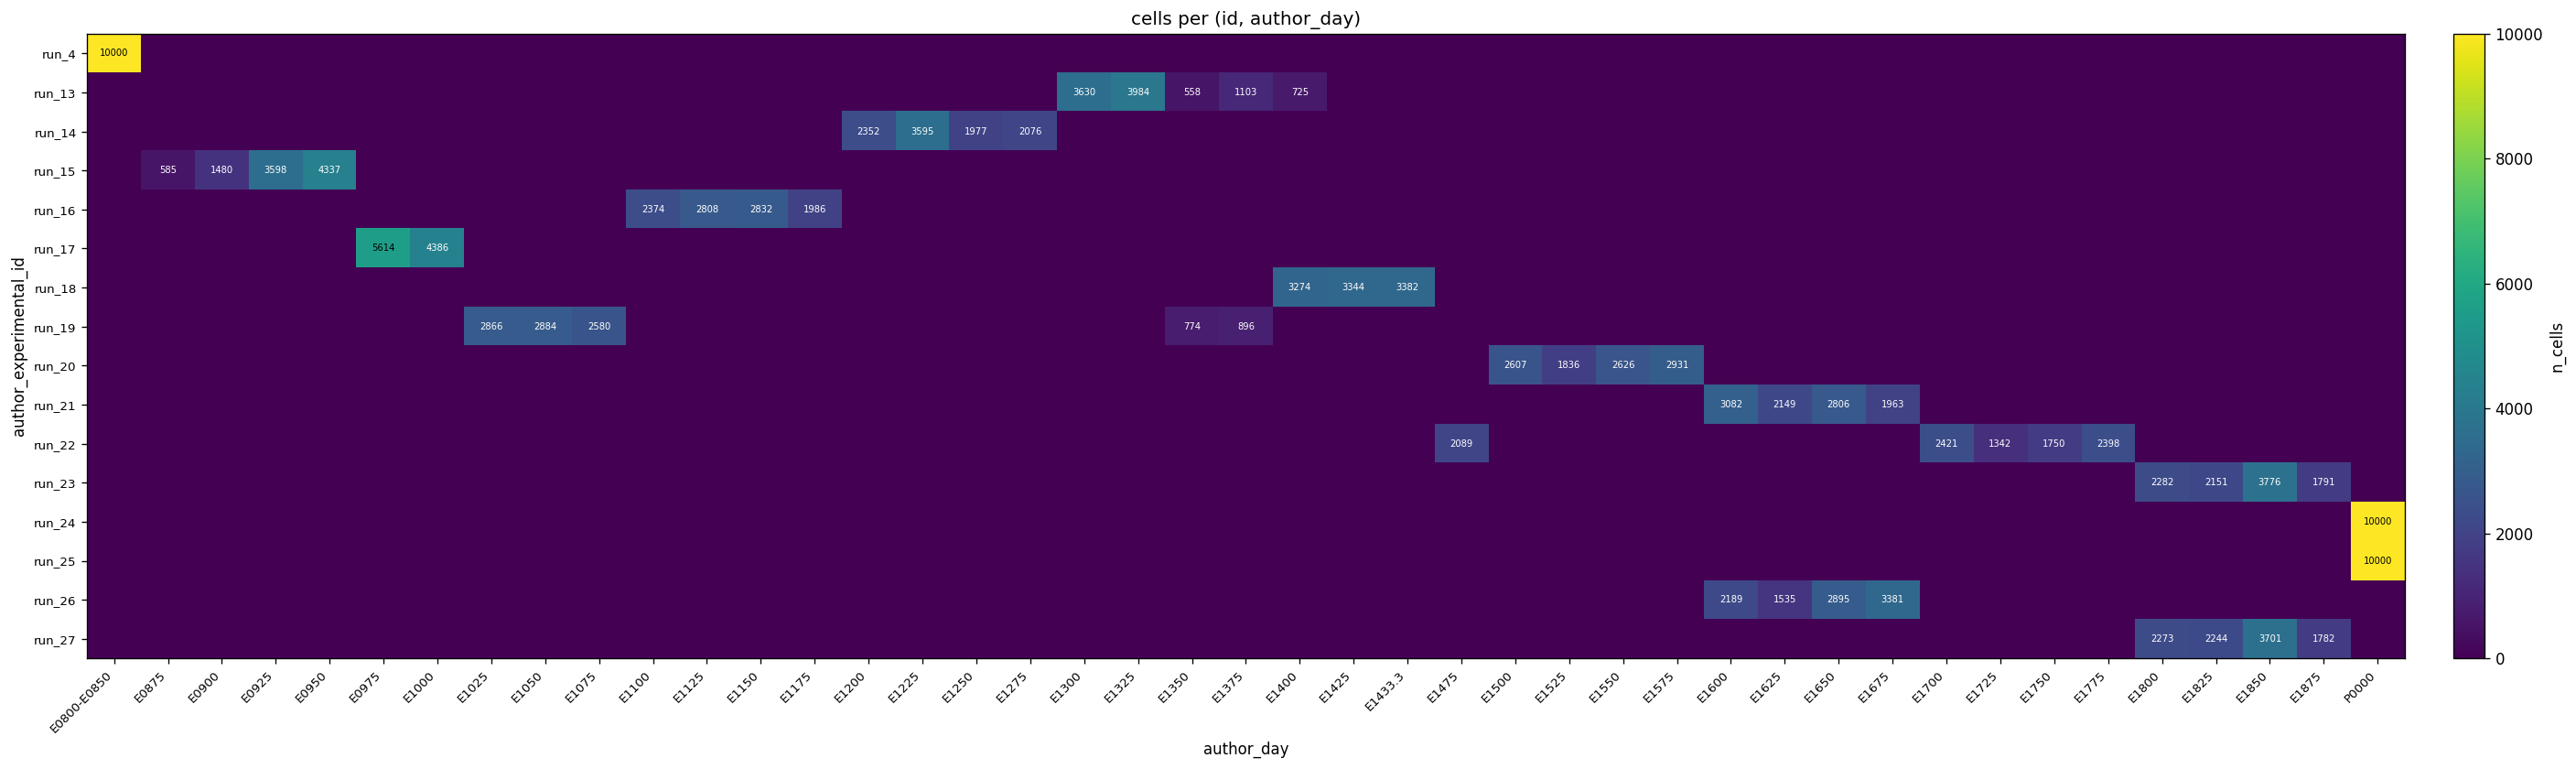

In [3]:
fig, ax = plt.subplots(figsize=(max(7, 0.55 * len(all_days)), 0.35 * len(ALL_IDS) + 1.5), dpi=120)
im = ax.imshow(M.values, cmap='viridis', aspect='auto')
ax.set_xticks(np.arange(len(all_days)))
ax.set_xticklabels(all_days, rotation=45, ha='right', fontsize=8)
ax.set_yticks(np.arange(len(ALL_IDS)))
ax.set_yticklabels(ALL_IDS, fontsize=8)
ax.set_xlabel('author_day')
ax.set_ylabel('author_experimental_id')
ax.set_title('cells per (id, author_day)')
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M.values[i, j]
        if v > 0:
            ax.text(j, i, f'{v}', ha='center', va='center', fontsize=6,
                    color='white' if v < M.values.max() * 0.5 else 'black')
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label='n_cells')
fig.tight_layout()
plt.show()
plt.close(fig)

## 2. Per-fold val vs train author_day breakdown

For each fold, the **left bar** is the held-out val id's day mix, the **right bar** is the train pool (15 ids concatenated). When the val bar shows a single colour the fold is degenerate (the LMI estimator gets a constant `Y` and returns 0).

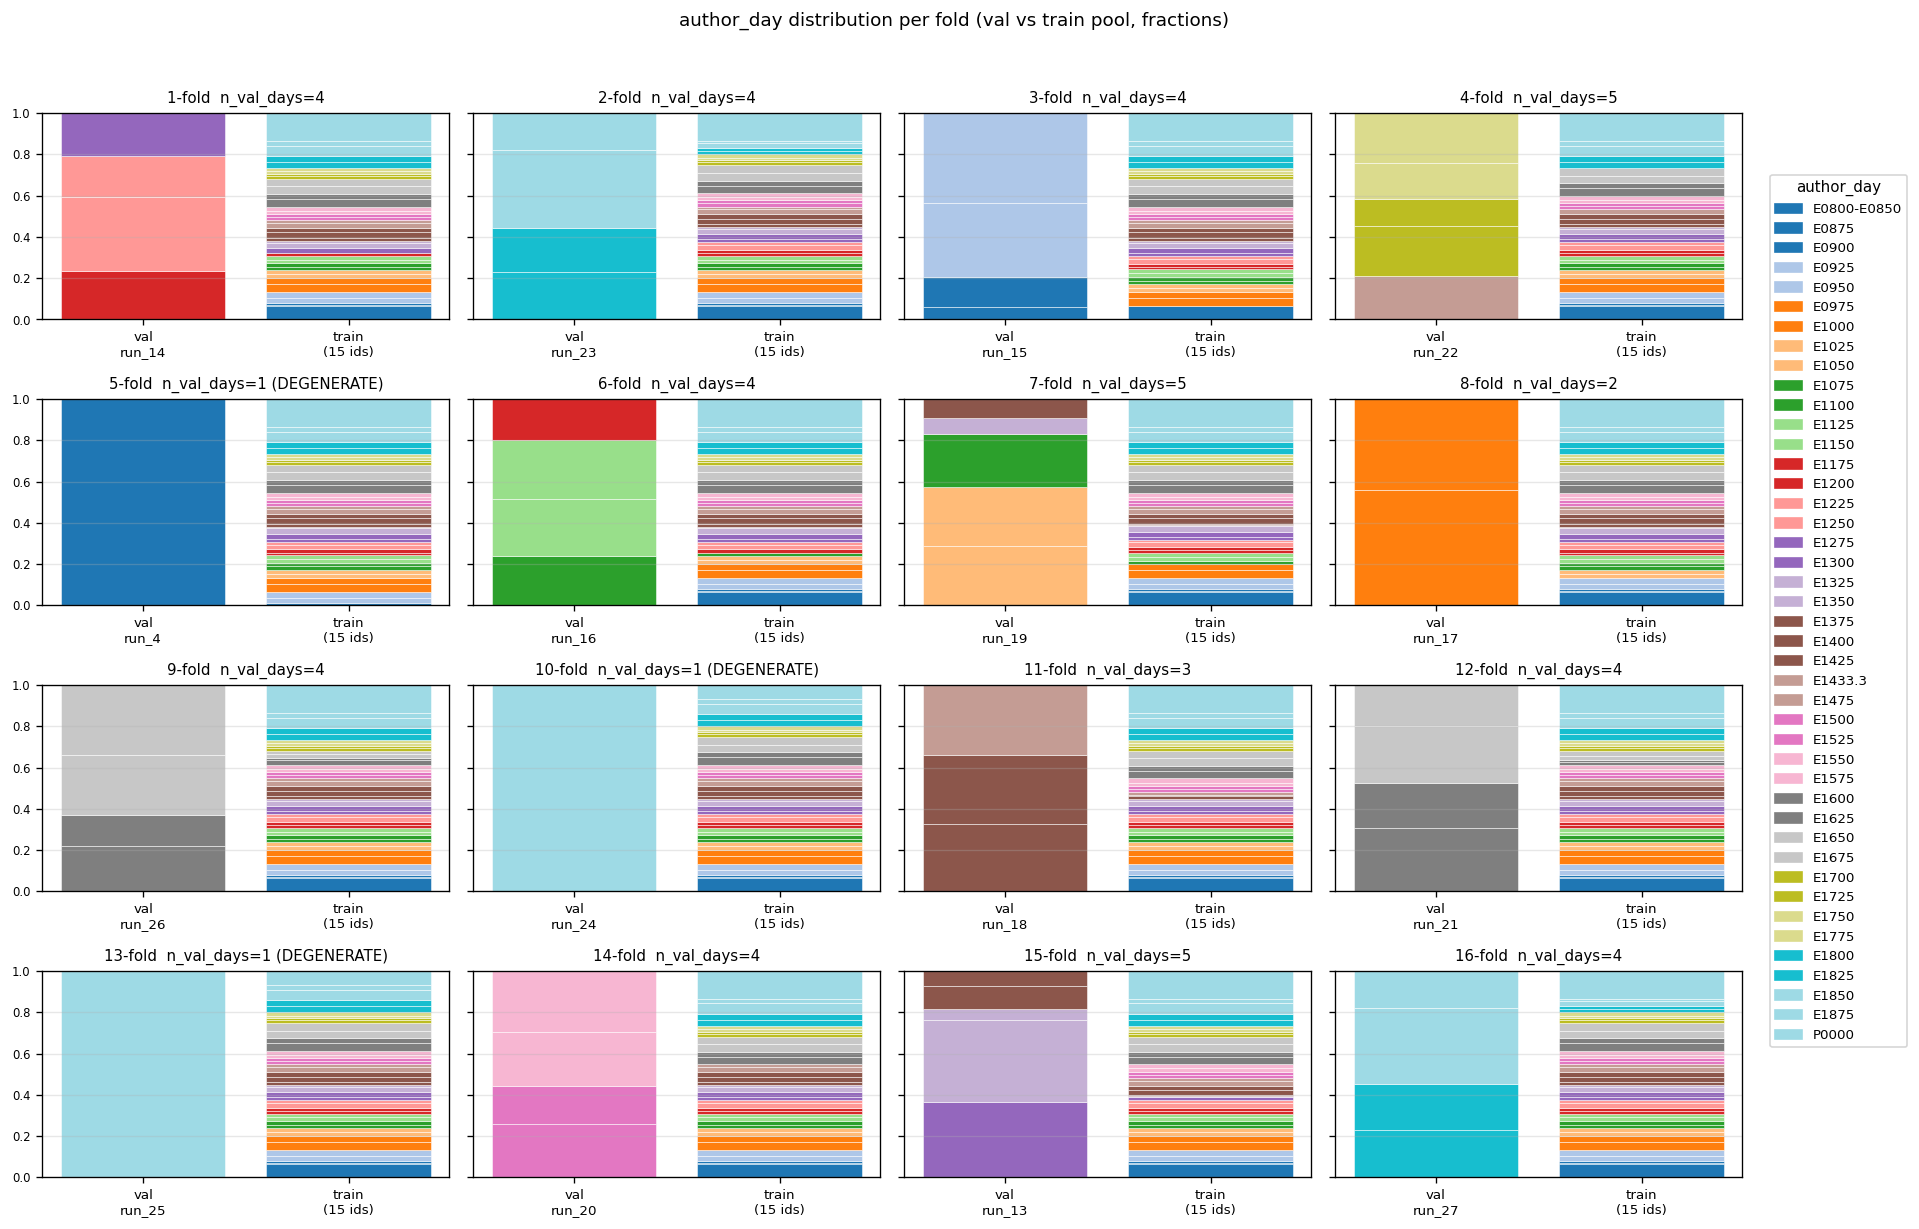

In [4]:
n_folds = len(FOLDS['folds'])
n_cols = 4
n_rows = int(np.ceil(n_folds / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.0 * n_cols, 2.6 * n_rows), dpi=120, sharey=True)
axes = axes.ravel()

cmap = plt.get_cmap('tab20', len(all_days))
day_to_color = {d: cmap(i) for i, d in enumerate(all_days)}

for ax, f in zip(axes, sorted(FOLDS['folds'], key=lambda x: x['fold'])):
    fold_label = f'{f["fold"]+1}-fold'
    val_id = f['val_ids'][0]
    train_ids = [t['id'] for t in f['train']]
    val_counts = M.loc[val_id]
    train_counts = M.loc[train_ids].sum(axis=0)
    val_frac = (val_counts / val_counts.sum()) if val_counts.sum() else val_counts
    train_frac = (train_counts / train_counts.sum()) if train_counts.sum() else train_counts

    bottom_v, bottom_t = 0.0, 0.0
    for d in all_days:
        v = float(val_frac[d]); t = float(train_frac[d])
        if v > 0:
            ax.bar(0, v, bottom=bottom_v, color=day_to_color[d], width=0.8, edgecolor='white', linewidth=0.3)
        if t > 0:
            ax.bar(1, t, bottom=bottom_t, color=day_to_color[d], width=0.8, edgecolor='white', linewidth=0.3)
        bottom_v += v; bottom_t += t

    n_val_days = int((val_counts > 0).sum())
    deg = ' (DEGENERATE)' if n_val_days == 1 else ''
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'val\n{val_id}', 'train\n(15 ids)'], fontsize=8)
    ax.set_ylim(0, 1.0)
    ax.set_title(f'{fold_label}  n_val_days={n_val_days}{deg}', fontsize=9)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(axis='y', alpha=0.3)

for ax in axes[n_folds:]:
    ax.set_visible(False)

handles = [plt.Rectangle((0,0),1,1, color=day_to_color[d]) for d in all_days]
fig.legend(handles, all_days, loc='center right', bbox_to_anchor=(1.0, 0.5),
           title='author_day', fontsize=8, title_fontsize=9, frameon=True)
fig.suptitle('author_day distribution per fold (val vs train pool, fractions)', fontsize=11)
fig.tight_layout(rect=[0, 0, 0.92, 0.96])
plt.show()
plt.close(fig)

## 3. Summary table: which folds are degenerate?

Counts the number of unique `author_day` values in the held-out val id, and the LMI value reported in `final_results/kfold_scvi_lmi.csv`. `n_val_days == 1` ⇒ MI must be 0.

In [5]:
csv = pd.read_csv('/home/igor/igor_repos/scaling_laws/Scaling-up-measurement-noise-scaling-laws/analysis/final_results/kfold_scvi_lmi.csv')
lmi_per_fold = csv.groupby('fold')['lmi'].agg(['mean', 'min', 'max'])
rows = []
for f in sorted(FOLDS['folds'], key=lambda x: x['fold']):
    fold_label = f'{f["fold"]+1}-fold'
    val_id = f['val_ids'][0]
    val_days = sorted(per_id_days[val_id].unique().tolist())
    n_val_days = len(val_days)
    lmi_row = lmi_per_fold.loc[fold_label] if fold_label in lmi_per_fold.index else None
    rows.append({
        'fold': fold_label,
        'val_id': val_id,
        'n_val_days': n_val_days,
        'val_days': ', '.join(val_days),
        'lmi_mean': float(lmi_row['mean']) if lmi_row is not None else float('nan'),
        'lmi_min': float(lmi_row['min']) if lmi_row is not None else float('nan'),
        'lmi_max': float(lmi_row['max']) if lmi_row is not None else float('nan'),
    })
summary = pd.DataFrame(rows).sort_values('fold', key=lambda s: s.map(lambda x: int(x.split('-')[0]))).reset_index(drop=True)
print('Degenerate folds (n_val_days == 1):')
print(summary[summary['n_val_days'] == 1][['fold', 'val_id', 'val_days', 'lmi_mean']].to_string(index=False))
print()
summary

Degenerate folds (n_val_days == 1):
   fold val_id    val_days  lmi_mean
 5-fold  run_4 E0800-E0850       0.0
10-fold run_24       P0000       0.0
13-fold run_25       P0000       0.0



,fold,val_id,n_val_days,val_days,lmi_mean,lmi_min,lmi_max
0,1-fold,run_14,4,"E1200, E1225, E1250, E1275",0.176444,0.123837,0.255142
1,2-fold,run_23,4,"E1800, E1825, E1850, E1875",0.238623,0.184249,0.364182
2,3-fold,run_15,4,"E0875, E0900, E0925, E0950",0.296867,0.236828,0.424259
3,4-fold,run_22,5,"E1475, E1700, E1725, E1750, E1775",0.436557,0.367702,0.503791
4,5-fold,run_4,1,E0800-E0850,0.000000,0.000000,0.000000
5,6-fold,run_16,4,"E1100, E1125, E1150, E1175",0.270581,0.222126,0.328411
6,7-fold,run_19,5,"E1025, E1050, E1075, E1350, E1375",0.678996,0.619986,0.725476
7,8-fold,run_17,2,"E0975, E1000",0.176799,0.139562,0.216996
8,9-fold,run_26,4,"E1600, E1625, E1650, E1675",0.212088,0.154147,0.260708
9,10-fold,run_24,1,P0000,0.000000,0.000000,0.000000
